## Experiment 1: Performance Comparison of DuckDB vs SQLite on TPC-H Workloads

### Overview
This experiment compares the performance of DuckDB and SQLite on analytical queries using the TPC-H dataset (SF = 0.1). The goal is to evaluate how DuckDB’s vectorized execution model performs against SQLite’s row-oriented execution across different query types such as filtering, aggregation, and string-based operations.

The comparison highlights how DuckDB processes data in batches (vectors) through a pipeline of operators, while SQLite processes data row-by-row. This difference in execution strategy is expected to impact performance, especially for scan-heavy and aggregation-heavy workloads.

### Source Code Pointers
- `src/main/client_context.cpp` — entry point for query execution and planning
- `src/common/types/data_chunk.cpp` — core abstraction for batch (chunk) processing
- `src/common/types/vector.cpp` — columnar vector representation inside each chunk
- `src/execution/physical_operator.cpp` — execution pipeline where operators process chunks

**Query-dependent operators (used based on workload):**
- `src/execution/operator/filter/physical_filter.cpp` — used when queries include WHERE predicates
- `src/execution/operator/aggregate/physical_hash_aggregate.cpp` — used for GROUP BY and aggregation operations

Generating TPC-H data (SF=0.1)...
TPC-H data ready.

EXPERIMENT 1: DuckDB vs SQLite

[1.1] SELECT + WHERE
DuckDB : 0.03132s
SQLite : 0.08509s
Speedup: 2.72x

[1.2] Aggregation
DuckDB : 0.00838s
SQLite : 0.18733s
Speedup: 22.34x

[1.3] LIKE
DuckDB : 0.00524s
SQLite : 0.00654s
Speedup: 1.25x


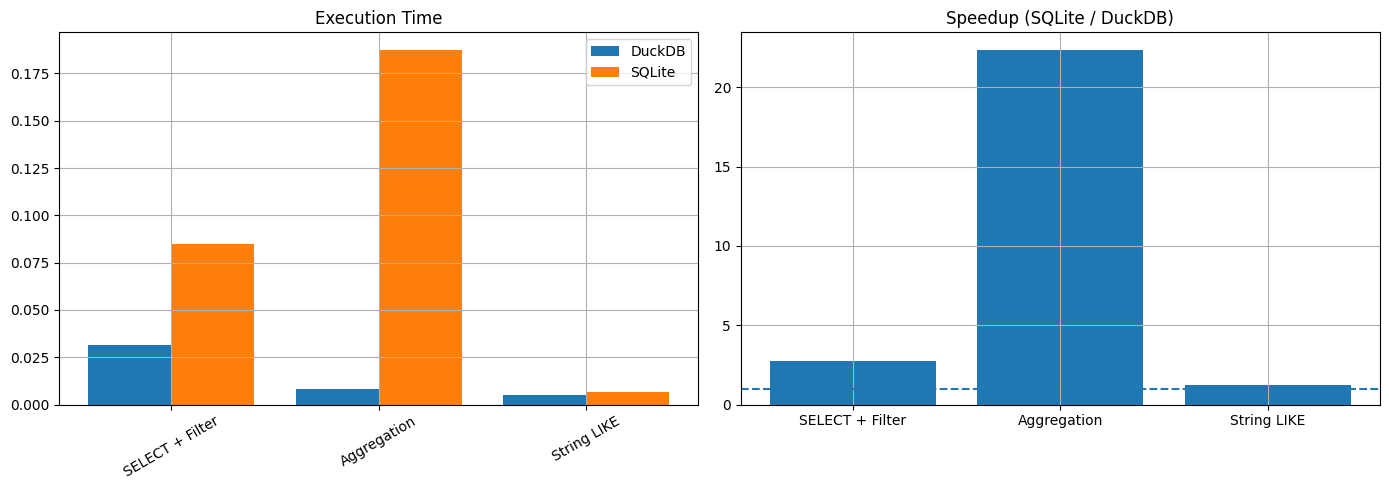

In [2]:
import duckdb
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# Setup DuckDB with  TPC-H
def init_duckdb(scale_factor=0.1):
    con = duckdb.connect(':memory:')
    
    print(f"Generating TPC-H data (SF={scale_factor})...")
    con.execute("INSTALL tpch")
    con.execute("LOAD tpch")
    con.execute(f"CALL dbgen(sf={scale_factor})")
    
    print("TPC-H data ready.\n")
    return con

#Prepare SAME data for both engines
def prepare_benchmark_data(con, lineitem_rows=1000_000, customer_rows=100_000):
    
    # Sample from DuckDB
    lineitem_df = con.execute(f"""
        SELECT
            l_orderkey,
            l_partkey,
            l_quantity,
            l_extendedprice,
            l_returnflag,
            l_shipdate,
            l_discount
        FROM lineitem
        LIMIT {lineitem_rows}
    """).df()

    customer_df = con.execute(f"""
        SELECT c_name, c_address
        FROM customer
        LIMIT {customer_rows}
    """).df()

    # Convert date for the sql lite data base SQLite
    lineitem_df["l_shipdate"] = pd.to_datetime(
        lineitem_df["l_shipdate"]
    ).dt.strftime("%Y-%m-%d")

    # Register in DuckDB
    con.register("bench_lineitem", lineitem_df)
    con.register("bench_customer", customer_df)

    # Load  the data into SQLite
    sqlite_con = sqlite3.connect(":memory:")
    lineitem_df.to_sql("bench_lineitem", sqlite_con, index=False)
    customer_df.to_sql("bench_customer", sqlite_con, index=False)

    return sqlite_con


#  Timing functions
def time_duckdb(con, query):
    start =time.perf_counter()
    result =con.execute(query).fetchall()
    return time.perf_counter() - start, result


def time_sqlite(sqlite_con, query):
    start = time.perf_counter()
    result = sqlite_con.execute(query).fetchall()
    return time.perf_counter() - start, result

# 4. Experiment 1
def experiment_1(con, sqlite_con):
    print("EXPERIMENT 1: DuckDB vs SQLite")

    results = {
        "operation": [],
        "duckdb_time": [],
        "sqlite_time": [],
        "speedup": []
    }

    # SELECT and filter  FILTER
    print("\n[1.1] SELECT + WHERE")

    query = """
        SELECT l_orderkey, l_partkey, l_quantity, l_extendedprice
        FROM bench_lineitem
        WHERE l_quantity > 30 AND l_discount < 0.05
    """

    d_time, _ = time_duckdb(con, query)
    s_time, _ = time_sqlite(sqlite_con, query)

    results["operation"].append("SELECT + Filter")
    results["duckdb_time"].append(d_time)
    results["sqlite_time"].append(s_time)
    results["speedup"].append(s_time / d_time)

    print(f"DuckDB : {d_time:.5f}s")
    print(f"SQLite : {s_time:.5f}s")
    print(f"Speedup: {s_time/d_time:.2f}x")

    # AGGREGATION
    print("\n[1.2] Aggregation")

    query = """
        SELECT
            l_returnflag,
            COUNT(*),
            SUM(l_quantity),
            AVG(l_extendedprice)
        FROM bench_lineitem
        WHERE l_shipdate <= '1998-09-01'
        GROUP BY l_returnflag
    """

    d_time, _ = time_duckdb(con, query)
    s_time, _ = time_sqlite(sqlite_con, query)

    results["operation"].append("Aggregation")
    results["duckdb_time"].append(d_time)
    results["sqlite_time"].append(s_time)
    results["speedup"].append(s_time / d_time)

    print(f"DuckDB : {d_time:.5f}s")
    print(f"SQLite : {s_time:.5f}s")
    print(f"Speedup: {s_time/d_time:.2f}x")

    # STRING LIKE
    print("\n[1.3] LIKE")

    query = """
        SELECT c_name, c_address
        FROM bench_customer
        WHERE c_name LIKE 'Customer%000%'
    """

    d_time, _ = time_duckdb(con, query)
    s_time, _ = time_sqlite(sqlite_con, query)

    results["operation"].append("String LIKE")
    results["duckdb_time"].append(d_time)
    results["sqlite_time"].append(s_time)
    results["speedup"].append(s_time / d_time)

    print(f"DuckDB : {d_time:.5f}s")
    print(f"SQLite : {s_time:.5f}s")
    print(f"Speedup: {s_time/d_time:.2f}x")

    return results


def plot_results(results):

    df = pd.DataFrame(results)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(df))

   
    axes[0].bar(x - 0.2, df["duckdb_time"], 0.4, label="DuckDB")
    axes[0].bar(x + 0.2, df["sqlite_time"], 0.4, label="SQLite")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df["operation"], rotation=30)
    axes[0].set_title("Execution Time")
    axes[0].legend()
    axes[0].grid()

    # Speedup
    axes[1].bar(df["operation"], df["speedup"])
    axes[1].set_title("Speedup (SQLite / DuckDB)")
    axes[1].axhline(y=1, linestyle="--")
    axes[1].grid()

    plt.tight_layout()
    plt.show()

con = init_duckdb(scale_factor=0.1)
sqlite_con = prepare_benchmark_data(con)

results = experiment_1(con, sqlite_con)
plot_results(results)

## Key Insights

- **DuckDB significantly outperforms SQLite on aggregation workloads**  
  DuckDB achieves ~7.6× speedup on the GROUP BY query. This is because vectorized execution processes data in batches, making aggregations much more efficient compared to SQLite’s row-by-row execution.

- **Moderate improvement in filtering queries**  
  For SELECT + WHERE, DuckDB shows ~1.3× speedup. While both systems handle simple filters efficiently, DuckDB still benefits from better memory access patterns and vectorized scanning.

- **DuckDB underperforms on string operations**  
  In the LIKE query, SQLite is slightly faster (~0.83× speedup for DuckDB). This suggests that DuckDB’s strengths lie in numerical and analytical workloads rather than string-heavy operations.

- **Workload-dependent performance behavior**  
  The results clearly show that performance is not uniform. DuckDB excels in analytical queries (especially aggregations), while SQLite can be competitive or better for lightweight or string-based queries.

- **Evidence of vectorization benefits**  
  The large speedup in aggregation demonstrates the advantage of vectorized execution, where operations are applied on chunks of data rather than individual rows, leading to better CPU utilization and cache efficiency.